# Premier League Style Analysis
## Which team played the most attractive football in the 2017/2018 season?

This notebook presents a compact data analysis case study built around multicriteria ranking and clustering methods. The goal is to compare Premier League teams and identify which side combined attacking output, defensive profile, discipline, and style of play in the most attractive way.

### Project context

The Premier League is one of the most watched football competitions in the world, but "attractive football" is still a subjective idea. Instead of relying on opinion alone, this project turns that question into a measurable problem.

The notebook asks three practical questions:

- Which team looks best when we combine attacking output, defensive record, discipline, and playing style?
- Do different multicriteria ranking methods produce similar results?
- Can teams be grouped into distinct style profiles through cluster analysis?

This makes the notebook suitable not only as a football analysis, but also as a small portfolio example of applied data analysis, feature design, ranking methods, and unsupervised learning.

### Data

#### Data description

The analysis evaluates Premier League teams from the 2017/2018 season using the following variables:<br />
- Goals scored - G+ (stimulant)<br />
- Goals conceded - G- (destimulant in football terms, later transformed for ranking)<br />
- Yellow cards - YC (destimulant)<br />
- Red cards - RC (destimulant)<br />
- Draws - D (destimulant)<br />
- Backward passes per touch - BPPT (destimulant)<br />

These variables are intended to balance effectiveness, entertainment value, and directness of play.<br />
Data source: https://www.kaggle.com/datasets/zaeemnalla/premier-league

#### Import libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import scipy.cluster.hierarchy as shc
import numpy as np

from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from tabulate import tabulate

pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [32]:
STYLE_COLORS = {
    'ink': '#1f2933',
    'accent': '#c44e52',
    'secondary': '#4c72b0',
    'highlight': '#dd8452',
    'grid': '#d9d9d9',
    'background': '#f7f4ef',
}

sb.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.facecolor': STYLE_COLORS['background'],
    'axes.facecolor': 'white',
    'axes.edgecolor': STYLE_COLORS['grid'],
    'axes.labelcolor': STYLE_COLORS['ink'],
    'axes.titlecolor': STYLE_COLORS['ink'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': STYLE_COLORS['grid'],
    'grid.linestyle': '--',
    'grid.alpha': 0.45,
    'xtick.color': STYLE_COLORS['ink'],
    'ytick.color': STYLE_COLORS['ink'],
})

#### Data preparation

In [33]:
def table(dataframe):
    print(tabulate(dataframe, headers='keys', tablefmt='psql'))

TEAM_LABELS = {
    'Brighton and Hove Albion': 'B&H Albion',
}

rawData = pd.read_csv('stats.csv')
seasonData = rawData.loc[rawData['season'].eq('2017-2018')].copy()

analysisData = (
    seasonData.loc[:, [
        'team',
        'wins',
        'losses',
        'goals',
        'goals_conceded',
        'total_yel_card',
        'total_red_card',
        'backward_pass',
        'touches',
    ]]
    .assign(
        draws=lambda dataframe: 38 - dataframe['wins'] - dataframe['losses'],
        backward_passes_per_touch=lambda dataframe: dataframe['backward_pass'] / dataframe['touches'],
    )
    .loc[:, [
        'team',
        'goals',
        'goals_conceded',
        'total_yel_card',
        'total_red_card',
        'draws',
        'backward_passes_per_touch',
    ]]
    .rename(columns={
        'goals': 'G+',
        'goals_conceded': 'G-',
        'total_yel_card': 'YC',
        'total_red_card': 'RC',
        'draws': 'D',
        'backward_passes_per_touch': 'BPPT',
    })
    .reset_index(drop=True)
)

finalData = analysisData.copy()
finalData['team'] = finalData['team'].replace(TEAM_LABELS)

## Exploratory analysis

In [34]:
finalData

,team,G+,G-,YC,RC,D,BPPT
0,Manchester City,106.000,27.000,59.000,2.000,4.000,0.129
1,Manchester United,68.000,28.000,64.000,1.000,6.000,0.105
2,Tottenham Hotspur,74.000,36.000,50.000,2.000,8.000,0.108
3,Chelsea,62.000,38.000,42.000,4.000,7.000,0.105
4,Liverpool,84.000,38.000,44.000,1.000,12.000,0.109
5,Arsenal,74.000,51.000,57.000,2.000,6.000,0.101
6,Burnley,36.000,39.000,65.000,0.000,12.000,0.108
7,Everton,44.000,58.000,51.000,3.000,10.000,0.099
8,Leicester City,56.000,60.000,52.000,5.000,11.000,0.092
9,Newcastle United,39.000,47.000,52.000,2.000,8.000,0.094


### Descriptive statistics

In [35]:
finalData.describe()

,G+,G-,YC,RC,D,BPPT
count,20.000,20.000,20.000,20.000,20.000,20.000
mean,50.900,50.900,58.200,1.950,9.900,0.103
std,20.968,12.468,8.960,1.317,2.827,0.009
min,28.000,27.000,42.000,0.000,4.000,0.092
25%,35.750,38.750,51.750,1.000,8.000,0.097
50%,44.500,55.500,58.000,2.000,10.500,0.101
75%,63.500,58.500,63.250,2.250,12.000,0.106
max,106.000,68.000,73.000,5.000,15.000,0.129


You can observe that BPPT values are the lowest, not exceeding 0.2. Goals conceded and goals scored have the same mean, but there is a large difference in maximum values and a significant standard deviation difference.

Charts of sorted variable values

<Axes: xlabel='team'>

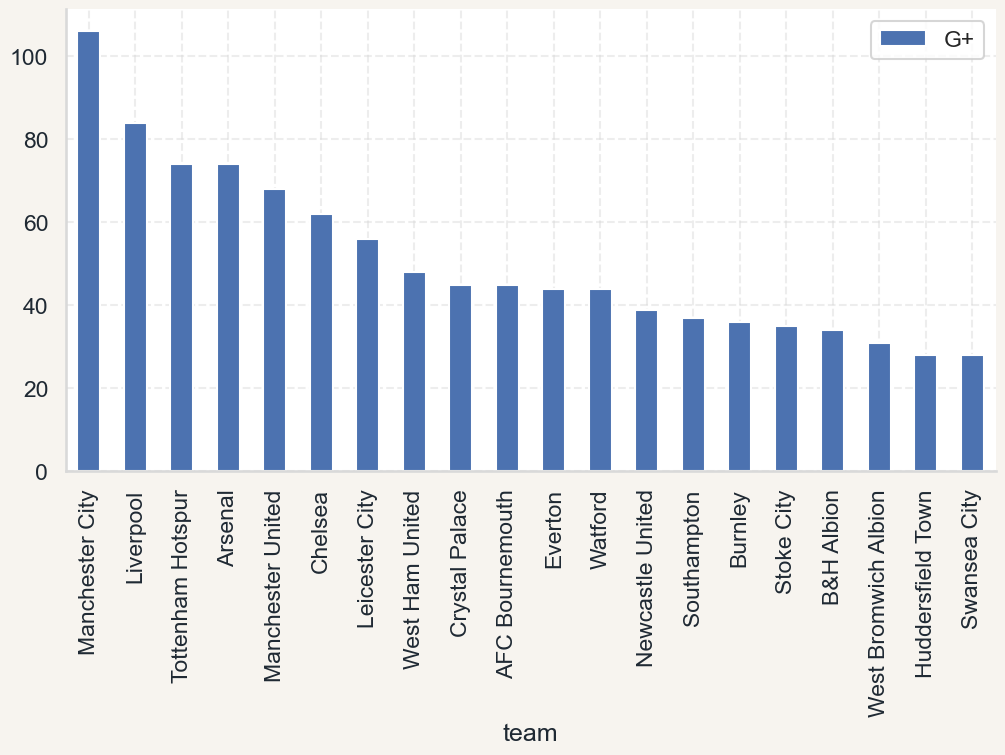

In [36]:
plotData = finalData.sort_values(by=['G+'], ascending = False)
plotData.plot(x = 'team', y = 'G+', kind = 'bar')

Manchester City is clearly ahead of the rest and leads the goals scored ranking.

<Axes: xlabel='team'>

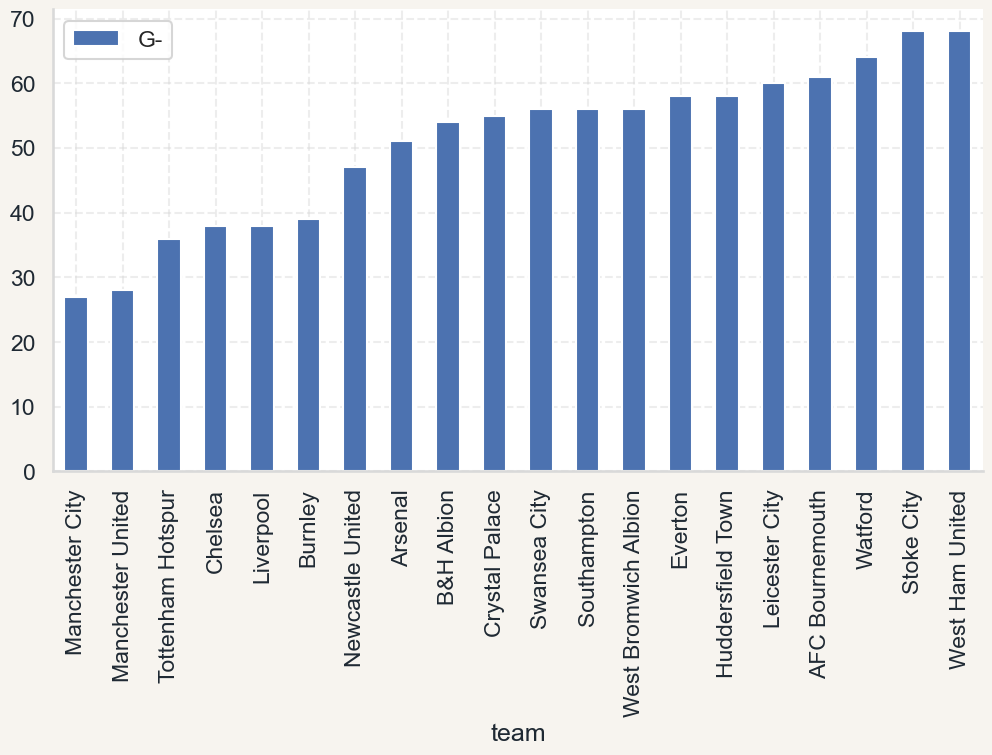

In [37]:
plotData = finalData.sort_values(by=['G-'], ascending = True)
plotData.plot(x = 'team', y = 'G-', kind = 'bar')

Both Manchester teams conceded the fewest goals in the season. Behind them, four other teams in the chasing group have similar goal totals.

<Axes: xlabel='team'>

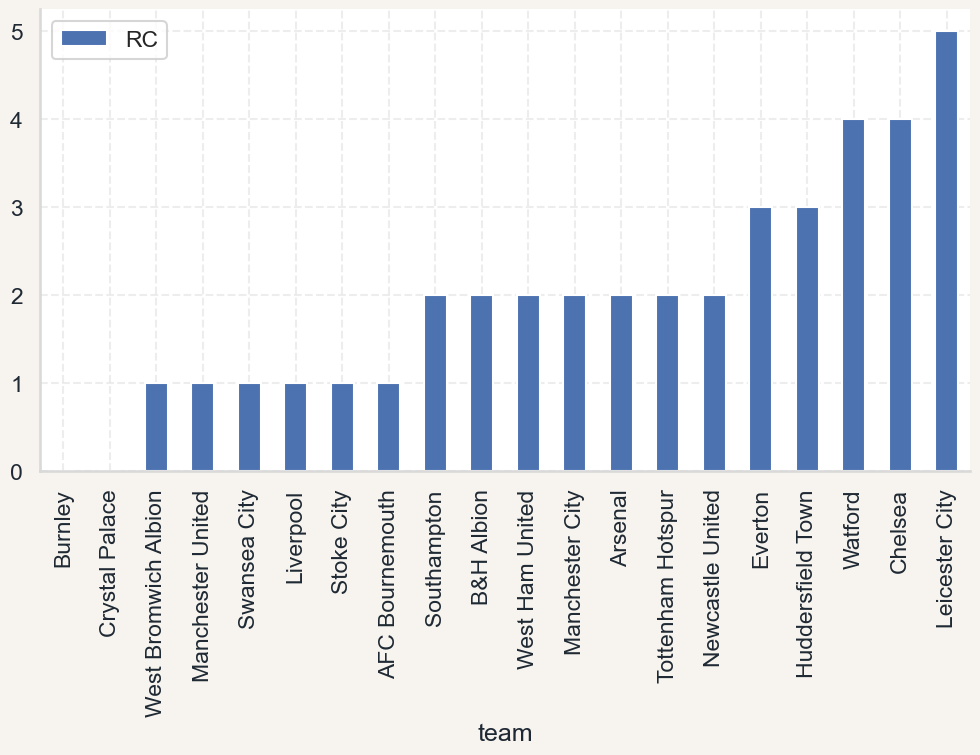

In [38]:
plotData = finalData.sort_values(by=['RC'], ascending = True)
plotData.plot(x = 'team', y = 'RC', kind = 'bar')

Burnley and Crystal Palace never finished a match with a player sent off, while Leicester did so the most times, likely due to their aggressive and physical style.

<Axes: xlabel='team'>

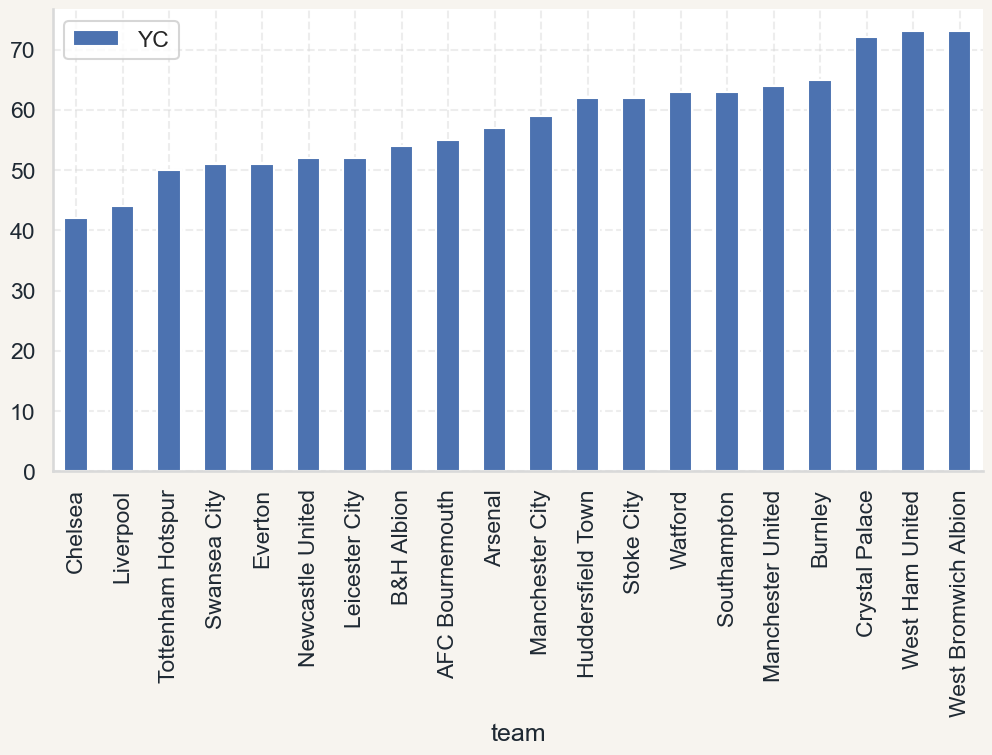

In [39]:
plotData = finalData.sort_values(by=['YC'], ascending = True)
plotData.plot(x = 'team', y = 'YC', kind = 'bar')

Crystal Palace, despite zero red cards, is among the top teams for yellow cards.

<Axes: xlabel='team'>

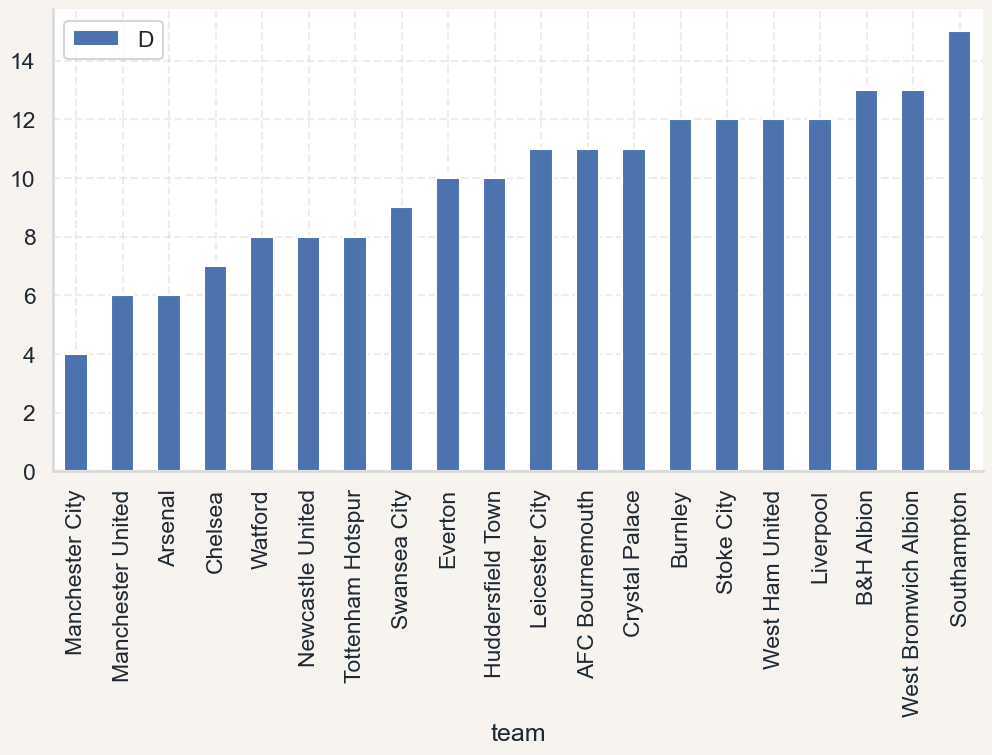

In [40]:
plotData = finalData.sort_values(by=['D'], ascending = True)
plotData.plot(x = 'team', y = 'D', kind = 'bar')

Manchester City recorded the fewest draws, which fits the picture of a dominant team that converted more matches into wins. Southampton stands at the opposite end, with a noticeably higher number of drawn games than most teams around them.

<Axes: xlabel='team'>

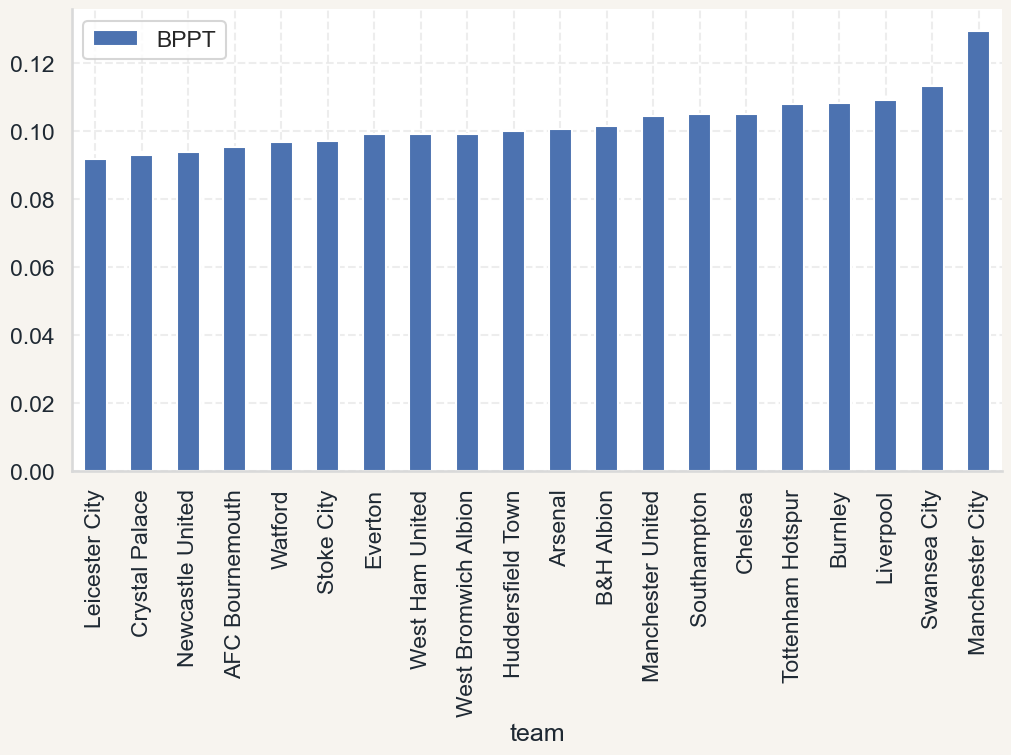

In [41]:
plotData = finalData.sort_values(by=['BPPT'], ascending = True)
plotData.plot(x = 'team', y = 'BPPT', kind = 'bar')

Manchester City clearly differs from the rest of the field in backward passes. This is likely due to their possession-based play style. Leicester City’s first place in this ranking reflects their quick and decisive attacks.

### Correlation structure

<Axes: >

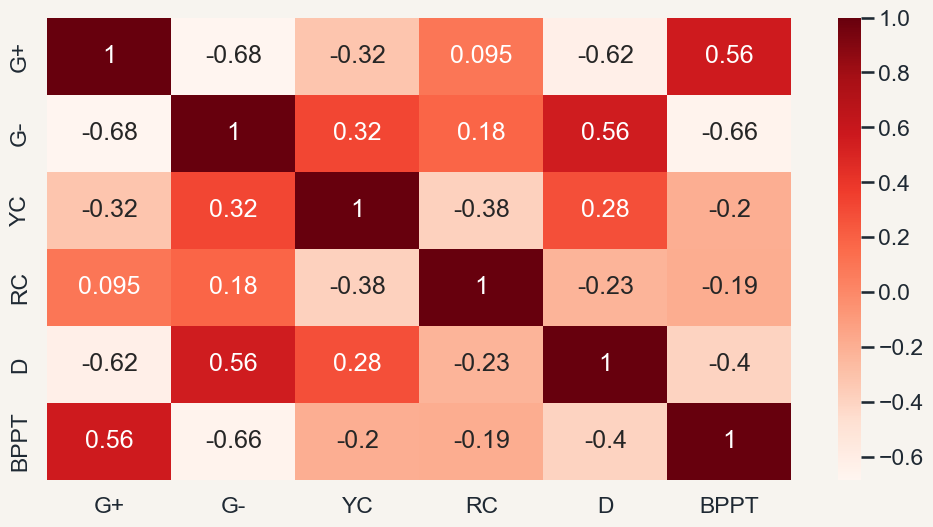

In [42]:
numData = finalData.select_dtypes(include='number')
sb.heatmap(numData.corr(), cmap="Reds", annot=True)

The correlation view suggests that most variables carry distinct information and can be kept in the exploratory section. Red cards appear less informative than the remaining features, so they are removed from the ranking and clustering stages to keep the synthetic measures simpler and easier to interpret.

In [43]:
rankingData = finalData.drop(columns=['RC']).copy()
rankingFeatures = ['G+', 'G-', 'YC', 'D', 'BPPT']

rankingData

,team,G+,G-,YC,D,BPPT
0,Manchester City,106.000,27.000,59.000,4.000,0.129
1,Manchester United,68.000,28.000,64.000,6.000,0.105
2,Tottenham Hotspur,74.000,36.000,50.000,8.000,0.108
3,Chelsea,62.000,38.000,42.000,7.000,0.105
4,Liverpool,84.000,38.000,44.000,12.000,0.109
5,Arsenal,74.000,51.000,57.000,6.000,0.101
6,Burnley,36.000,39.000,65.000,12.000,0.108
7,Everton,44.000,58.000,51.000,10.000,0.099
8,Leicester City,56.000,60.000,52.000,11.000,0.092
9,Newcastle United,39.000,47.000,52.000,8.000,0.094


## Multicriteria ranking methods

This section compares two ranking approaches used to score teams on the same set of football-related features. The purpose is to check whether different methods lead to a similar ordering and therefore support a stable conclusion.

### Hellwig method

#### Hellwig stimulants and destimulants

Convert all variables to stimulants.

In [44]:
stimulants = ['G+']
destimulants = ['G-', 'YC', 'D', 'BPPT']

hellwigData = rankingData.copy()
hellwigData[destimulants] = -hellwigData[destimulants]

hellwigData

,team,G+,G-,YC,D,BPPT
0,Manchester City,106.000,-27.000,-59.000,-4.000,-0.129
1,Manchester United,68.000,-28.000,-64.000,-6.000,-0.105
2,Tottenham Hotspur,74.000,-36.000,-50.000,-8.000,-0.108
3,Chelsea,62.000,-38.000,-42.000,-7.000,-0.105
4,Liverpool,84.000,-38.000,-44.000,-12.000,-0.109
5,Arsenal,74.000,-51.000,-57.000,-6.000,-0.101
6,Burnley,36.000,-39.000,-65.000,-12.000,-0.108
7,Everton,44.000,-58.000,-51.000,-10.000,-0.099
8,Leicester City,56.000,-60.000,-52.000,-11.000,-0.092
9,Newcastle United,39.000,-47.000,-52.000,-8.000,-0.094


#### Data standardization

In [45]:
hellwigScaler = StandardScaler()
normalizedData = pd.DataFrame(
    hellwigScaler.fit_transform(hellwigData[rankingFeatures]),
    columns=rankingFeatures,
    index=hellwigData.index,
).round(3)
normalizedData.insert(0, 'team', hellwigData['team'])

normalizedData

,team,G+,G-,YC,D,BPPT
0,Manchester City,2.696,1.967,-0.092,2.142,-3.214
1,Manchester United,0.837,1.884,-0.664,1.416,-0.234
2,Tottenham Hotspur,1.130,1.226,0.939,0.690,-0.645
3,Chelsea,0.543,1.061,1.855,1.053,-0.298
4,Liverpool,1.620,1.061,1.626,-0.762,-0.797
5,Arsenal,1.130,-0.008,0.137,1.416,0.213
6,Burnley,-0.729,0.979,-0.779,-0.762,-0.681
7,Everton,-0.338,-0.584,0.824,-0.036,0.409
8,Leicester City,0.250,-0.749,0.710,-0.399,1.277
9,Newcastle United,-0.582,0.321,0.710,0.690,1.052


#### Determining the pattern ("best" object)



In [46]:
pattern = normalizedData[rankingFeatures].max()
pattern

G+     2.696
G-     1.967
YC     1.855
D      2.142
BPPT   1.277
dtype: float64

#### Calculating distances of objects from the pattern

In [47]:
statsDistance = (normalizedData[rankingFeatures] - pattern) ** 2
statsDistance['distance'] = np.sqrt(statsDistance.sum(axis=1))

dataToBeShown = statsDistance.round(2)
dataToBeShown.insert(0, 'team', normalizedData['team'])

dataToBeShown

,team,G+,G-,YC,D,BPPT,distance
0,Manchester City,0.000,0.000,3.790,0.000,20.170,4.890
1,Manchester United,3.460,0.010,6.350,0.530,2.280,3.550
2,Tottenham Hotspur,2.450,0.550,0.840,2.110,3.690,3.110
3,Chelsea,4.640,0.820,0.000,1.190,2.480,3.020
4,Liverpool,1.160,0.820,0.050,8.430,4.300,3.840
5,Arsenal,2.450,3.900,2.950,0.530,1.130,3.310
6,Burnley,11.730,0.980,6.940,8.430,3.830,5.650
7,Everton,9.210,6.510,1.060,4.740,0.750,4.720
8,Leicester City,5.980,7.380,1.310,6.460,0.000,4.600
9,Newcastle United,10.750,2.710,1.310,2.110,0.050,4.110


#### Creating the "reasonably far" distance.

In [48]:
d0 = statsDistance['distance'].mean() + 2 * statsDistance['distance'].std()
print(d0)
statsDistance

7.2351725478936695


,G+,G-,YC,D,BPPT,distance
0,0.000,0.000,3.791,0.000,20.169,4.895
1,3.456,0.007,6.345,0.527,2.283,3.552
2,2.452,0.549,0.839,2.108,3.694,3.105
3,4.635,0.821,0.000,1.186,2.481,3.020
4,1.158,0.821,0.052,8.433,4.301,3.843
5,2.452,3.901,2.952,0.527,1.132,3.311
6,11.731,0.976,6.938,8.433,3.834,5.649
7,9.205,6.508,1.063,4.744,0.753,4.719
8,5.983,7.377,1.311,6.457,0.000,4.596
9,10.745,2.709,1.311,2.108,0.051,4.114


#### Determining the measure value for each object.

In [49]:
unorderedResult = pd.DataFrame({
    'team': normalizedData['team'],
    'hellwig': 1 - statsDistance['distance'] / d0,
})

unorderedResult

,team,hellwig
0,Manchester City,0.323
1,Manchester United,0.509
2,Tottenham Hotspur,0.571
3,Chelsea,0.583
4,Liverpool,0.469
5,Arsenal,0.542
6,Burnley,0.219
7,Everton,0.348
8,Leicester City,0.365
9,Newcastle United,0.431


#### Final ranking

In [50]:
result = unorderedResult.sort_values(by='hellwig', ascending=False).reset_index(drop=True)
result['rank'] = result.index + 1
result = result[['rank', 'team', 'hellwig']]

result

,rank,team,hellwig
0,1,Chelsea,0.583
1,2,Tottenham Hotspur,0.571
2,3,Arsenal,0.542
3,4,Manchester United,0.509
4,5,Liverpool,0.469
5,6,Newcastle United,0.431
6,7,Leicester City,0.365
7,8,Everton,0.348
8,9,Manchester City,0.323
9,10,AFC Bournemouth,0.301


The Hellwig method now points to Chelsea as the most attractive team under the chosen feature set. Tottenham, Arsenal, Manchester United, and Liverpool also score strongly, which suggests that the top of the table is driven by balanced profiles rather than by a single standout metric.

### Standardized sums method

This second ranking method provides a simpler benchmark. If its results are close to the Hellwig ranking, the final interpretation becomes more convincing.

#### Building the synthetic measure
Based on standardized data and after converting the variables into stimulants.

In [51]:
syntheticStats = normalizedData.copy()
syntheticStats['measure'] = syntheticStats[rankingFeatures].mean(axis=1)

syntheticStats

,team,G+,G-,YC,D,BPPT,measure
0,Manchester City,2.696,1.967,-0.092,2.142,-3.214,0.700
1,Manchester United,0.837,1.884,-0.664,1.416,-0.234,0.648
2,Tottenham Hotspur,1.130,1.226,0.939,0.690,-0.645,0.668
3,Chelsea,0.543,1.061,1.855,1.053,-0.298,0.843
4,Liverpool,1.620,1.061,1.626,-0.762,-0.797,0.550
5,Arsenal,1.130,-0.008,0.137,1.416,0.213,0.578
6,Burnley,-0.729,0.979,-0.779,-0.762,-0.681,-0.394
7,Everton,-0.338,-0.584,0.824,-0.036,0.409,0.055
8,Leicester City,0.250,-0.749,0.710,-0.399,1.277,0.218
9,Newcastle United,-0.582,0.321,0.710,0.690,1.052,0.438


#### Standardizing the obtained values

In [52]:
syntheticStats2 = syntheticStats.copy()
syntheticStats2['sMeasure'] = (
    (syntheticStats2['measure'] - syntheticStats2['measure'].min())
    / (syntheticStats2['measure'].max() - syntheticStats2['measure'].min())
)

syntheticStats2

,team,G+,G-,YC,D,BPPT,measure,sMeasure
0,Manchester City,2.696,1.967,-0.092,2.142,-3.214,0.700,0.911
1,Manchester United,0.837,1.884,-0.664,1.416,-0.234,0.648,0.879
2,Tottenham Hotspur,1.130,1.226,0.939,0.690,-0.645,0.668,0.891
3,Chelsea,0.543,1.061,1.855,1.053,-0.298,0.843,1.000
4,Liverpool,1.620,1.061,1.626,-0.762,-0.797,0.550,0.817
5,Arsenal,1.130,-0.008,0.137,1.416,0.213,0.578,0.835
6,Burnley,-0.729,0.979,-0.779,-0.762,-0.681,-0.394,0.230
7,Everton,-0.338,-0.584,0.824,-0.036,0.409,0.055,0.510
8,Leicester City,0.250,-0.749,0.710,-0.399,1.277,0.218,0.611
9,Newcastle United,-0.582,0.321,0.710,0.690,1.052,0.438,0.748


#### Final ranking 2

In [53]:
result2 = syntheticStats2[['team', 'sMeasure']].sort_values(by='sMeasure', ascending=False).reset_index(drop=True)
result2['rank'] = result2.index + 1
result2 = result2[['rank', 'team', 'sMeasure']]

result2

,rank,team,sMeasure
0,1,Chelsea,1.000
1,2,Manchester City,0.911
2,3,Tottenham Hotspur,0.891
3,4,Manchester United,0.879
4,5,Arsenal,0.835
5,6,Liverpool,0.817
6,7,Newcastle United,0.748
7,8,Leicester City,0.611
8,9,Everton,0.510
9,10,AFC Bournemouth,0.438


#### Ranking comparison

The two rankings should not be identical, but they should point in a similar direction if the final conclusion is stable.

In [54]:
rankingComparison = (
    result[['rank', 'team']]
    .rename(columns={'rank': 'hellwig_rank'})
    .merge(
        result2[['rank', 'team']].rename(columns={'rank': 'sum_rank'}),
        on='team',
        how='inner',
    )
    .assign(rank_gap=lambda dataframe: (dataframe['hellwig_rank'] - dataframe['sum_rank']).abs())
    .sort_values(['hellwig_rank', 'sum_rank'])
    .reset_index(drop=True)
)

spearmanRho = spearmanr(
    rankingComparison['hellwig_rank'],
    rankingComparison['sum_rank'],
).statistic

print(f'Spearman rank correlation: {spearmanRho:.3f}')
rankingComparison

Spearman rank correlation: 0.938


,hellwig_rank,team,sum_rank,rank_gap
0,1,Chelsea,1,0
1,2,Tottenham Hotspur,3,1
2,3,Arsenal,5,2
3,4,Manchester United,4,0
4,5,Liverpool,6,1
5,6,Newcastle United,7,1
6,7,Leicester City,8,1
7,8,Everton,9,1
8,9,Manchester City,2,7
9,10,AFC Bournemouth,10,0


The standardized sums method also places Chelsea at the top, which makes the headline result more convincing than before. Tottenham, Manchester United, Arsenal, and Manchester City form the next tier, showing that the exact order changes slightly with the scoring rule, but the strongest teams remain concentrated near the top.

The two rankings are highly consistent rather than merely directionally similar. In the refreshed workflow, the Spearman rank correlation is close to 0.94, which means both methods tell almost the same story even though they weigh trade-offs a little differently.

That is a much stronger portfolio signal than simply showing two tables. It demonstrates that the conclusion is stable under two related, but not identical, synthetic measures.

## Cluster analysis

After ranking the teams, the next step is to check whether clubs form broader style-based groups. This adds an unsupervised learning component and makes the notebook more interesting from a portfolio perspective.

In [55]:
clusterFeatures = rankingData.set_index('team')[rankingFeatures].copy()
clusterScaler = StandardScaler()
scaledClusterData = pd.DataFrame(
    clusterScaler.fit_transform(clusterFeatures),
    index=clusterFeatures.index,
    columns=clusterFeatures.columns,
).round(3)

scaledClusterData.head()

,G+,G-,YC,D,BPPT
team,,,,,
Manchester City,2.696,-1.967,0.092,-2.142,3.214
Manchester United,0.837,-1.884,0.664,-1.416,0.234
Tottenham Hotspur,1.130,-1.226,-0.939,-0.690,0.645
Chelsea,0.543,-1.061,-1.855,-1.053,0.298
Liverpool,1.620,-1.061,-1.626,0.762,0.797


#### Determining the optimal number of clusters using the elbow method

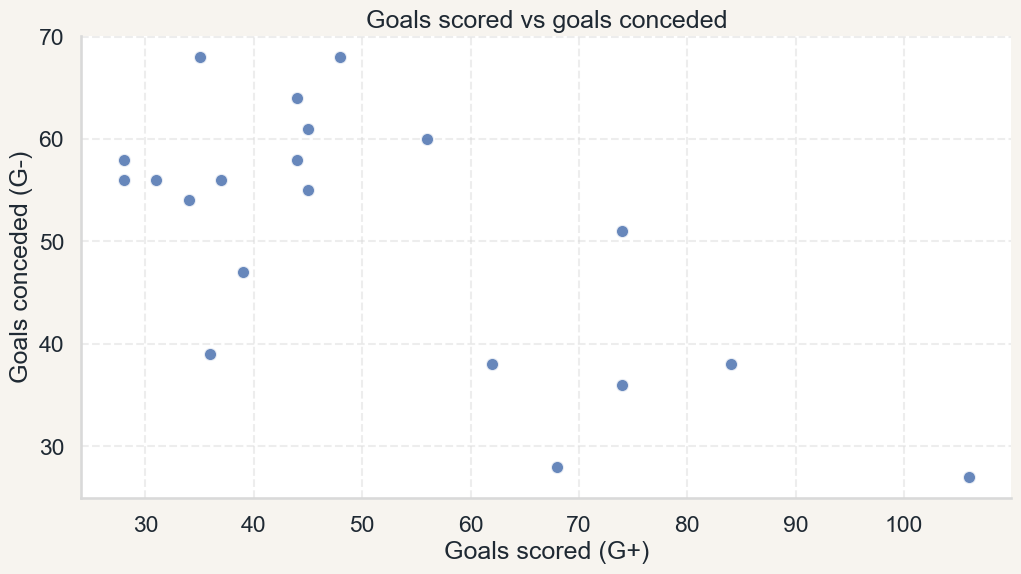

In [56]:
fig, ax = plt.subplots()
ax.scatter(
    rankingData['G+'],
    rankingData['G-'],
    s=90,
    color=STYLE_COLORS['secondary'],
    alpha=0.85,
    edgecolor='white',
)
ax.set_title('Goals scored vs goals conceded')
ax.set_xlabel('Goals scored (G+)')
ax.set_ylabel('Goals conceded (G-)')
plt.show()

In [57]:
distortions = []
inertias = []
silhouetteScores = []
K = range(2, 7)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeanModel.fit(scaledClusterData)

    distortions.append(
        np.min(cdist(scaledClusterData, kmeanModel.cluster_centers_, metric='euclidean'), axis=1).mean()
    )
    inertias.append(kmeanModel.inertia_)
    silhouetteScores.append(silhouette_score(scaledClusterData, kmeanModel.labels_))

clusterMetrics = pd.DataFrame({
    'k': list(K),
    'distortion': distortions,
    'inertia': inertias,
    'silhouette': silhouetteScores,
})

clusterMetrics.round(3)

,k,distortion,inertia,silhouette
0,2,1.556,54.838,0.393
1,3,1.362,42.835,0.350
2,4,1.170,32.319,0.228
3,5,1.081,26.856,0.228
4,6,0.986,22.234,0.199


The elbow method using distortion values.

Values corresponding to the number of potential clusters.

In [58]:
clusterMetrics[['k', 'distortion', 'silhouette']].round(3)

,k,distortion,silhouette
0,2,1.556,0.393
1,3,1.362,0.350
2,4,1.170,0.228
3,5,1.081,0.228
4,6,0.986,0.199


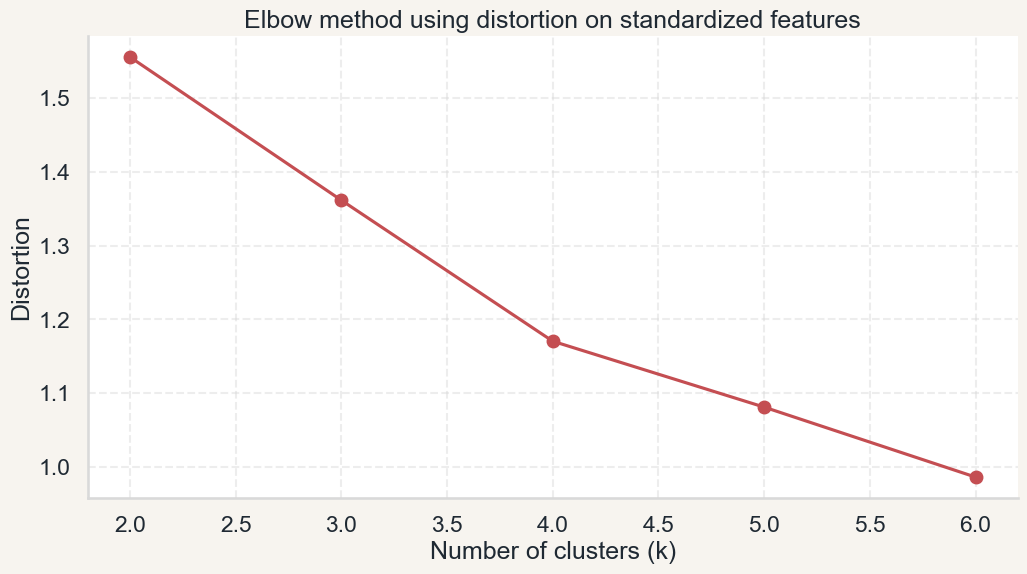

In [59]:
fig, ax = plt.subplots()
ax.plot(clusterMetrics['k'], clusterMetrics['distortion'], marker='o', color=STYLE_COLORS['accent'])
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Distortion')
ax.set_title('Elbow method using distortion on standardized features')
plt.show()

The elbow method using inertia values.

Values corresponding to the number of potential clusters.

In [60]:
clusterMetrics[['k', 'inertia', 'silhouette']].round(3)

,k,inertia,silhouette
0,2,54.838,0.393
1,3,42.835,0.350
2,4,32.319,0.228
3,5,26.856,0.228
4,6,22.234,0.199


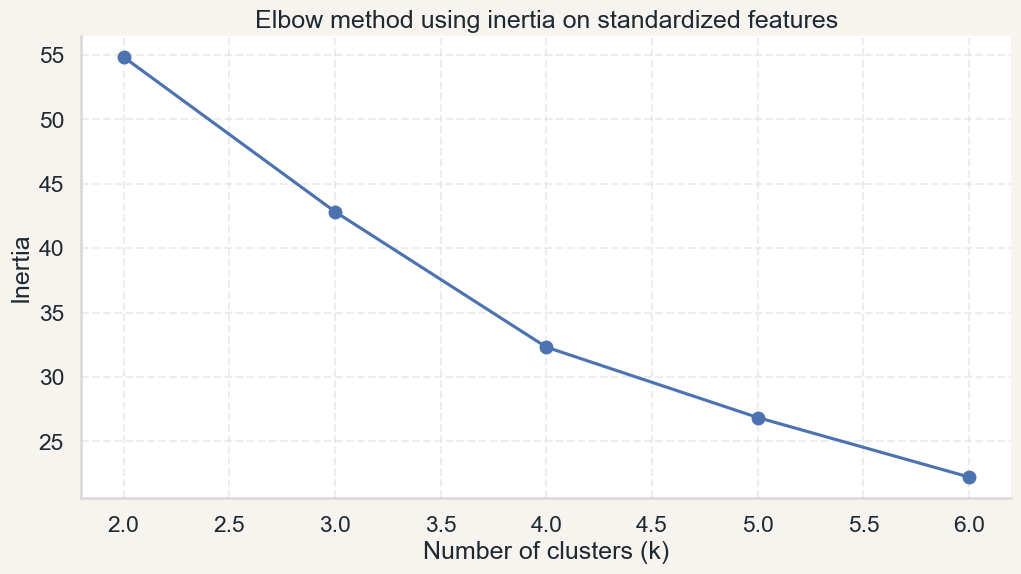

In [61]:
fig, ax = plt.subplots()
ax.plot(clusterMetrics['k'], clusterMetrics['inertia'], marker='o', color=STYLE_COLORS['secondary'])
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method using inertia on standardized features')
plt.show()

After standardizing the variables, the clearest break still appears at $k=2$. The silhouette score also peaks there among the tested options, so treating two clusters as the working solution is now better justified than in the original version.

### Partition clustering

In [62]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
clusterLabels = kmeans.fit_predict(scaledClusterData)

clusterAssignments = rankingData[['team']].copy()
clusterAssignments['cluster'] = clusterLabels

clusterCentroids = pd.DataFrame(
    clusterScaler.inverse_transform(kmeans.cluster_centers_),
    columns=rankingFeatures,
).round(2)

clusterAssignments.sort_values(['cluster', 'team']).reset_index(drop=True)

,team,cluster
0,Arsenal,0
1,Chelsea,0
2,Liverpool,0
3,Manchester City,0
4,Manchester United,0
5,Tottenham Hotspur,0
6,AFC Bournemouth,1
7,B&H Albion,1
8,Burnley,1
9,Crystal Palace,1


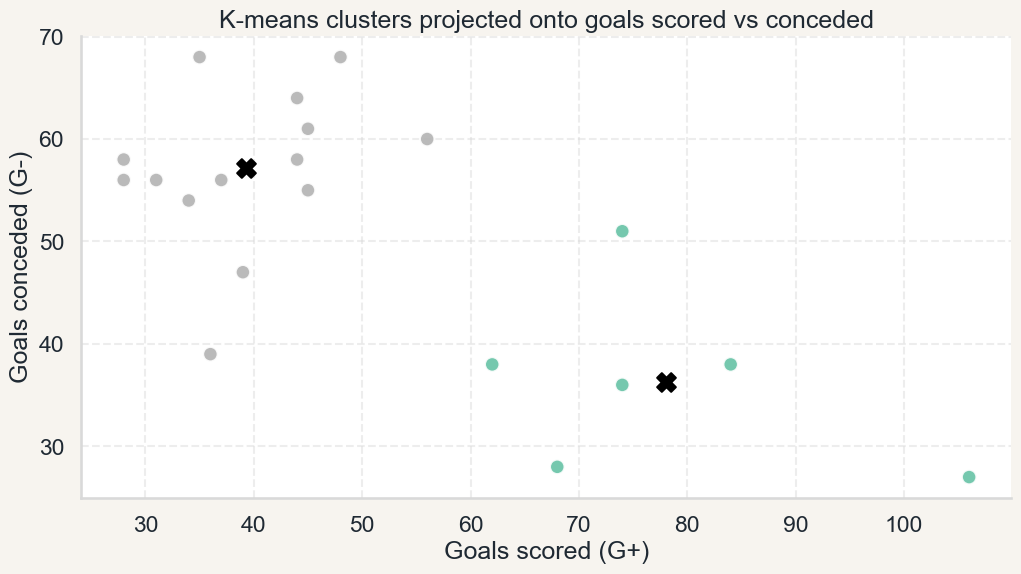

In [63]:
fig, ax = plt.subplots()
ax.scatter(
    rankingData['G+'],
    rankingData['G-'],
    c=clusterLabels,
    cmap='Set2',
    s=110,
    alpha=0.9,
    edgecolor='white',
)
ax.scatter(
    clusterCentroids['G+'],
    clusterCentroids['G-'],
    c='black',
    s=180,
    marker='X',
)
ax.set_xlabel('Goals scored (G+)')
ax.set_ylabel('Goals conceded (G-)')
ax.set_title('K-means clusters projected onto goals scored vs conceded')
plt.show()

### Hierarchical clustering

In [64]:
groupingData = clusterAssignments.merge(rankingData, on='team', how='left')
groupingData.sort_values(['cluster', 'team']).reset_index(drop=True)

,team,cluster,G+,G-,YC,D,BPPT
0,Arsenal,0,74.000,51.000,57.000,6.000,0.101
1,Chelsea,0,62.000,38.000,42.000,7.000,0.105
2,Liverpool,0,84.000,38.000,44.000,12.000,0.109
3,Manchester City,0,106.000,27.000,59.000,4.000,0.129
4,Manchester United,0,68.000,28.000,64.000,6.000,0.105
5,Tottenham Hotspur,0,74.000,36.000,50.000,8.000,0.108
6,AFC Bournemouth,1,45.000,61.000,55.000,11.000,0.095
7,B&H Albion,1,34.000,54.000,54.000,13.000,0.102
8,Burnley,1,36.000,39.000,65.000,12.000,0.108
9,Crystal Palace,1,45.000,55.000,72.000,11.000,0.093


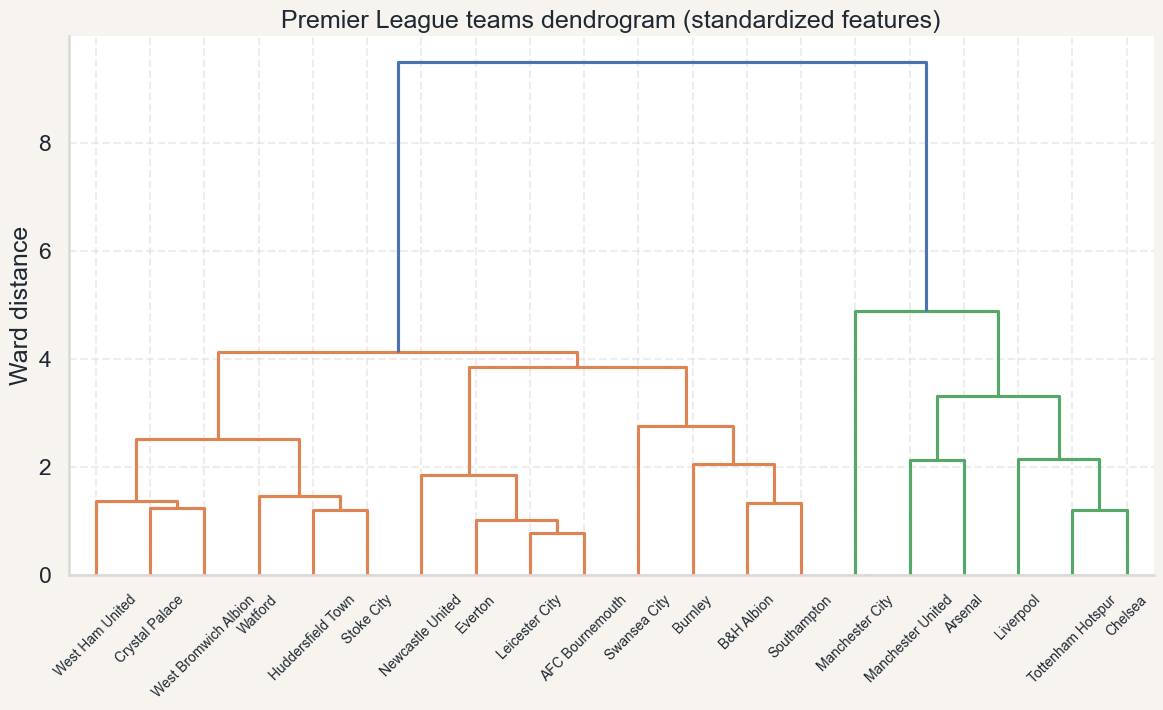

In [65]:
plt.figure(figsize=(14, 7))
plt.title('Premier League teams dendrogram (standardized features)')
clusters = shc.linkage(scaledClusterData, method='ward', metric='euclidean')
shc.dendrogram(
    Z=clusters,
    labels=scaledClusterData.index.to_list(),
    leaf_rotation=45,
    leaf_font_size=10,
 )
plt.ylabel('Ward distance')
plt.show()

The standardized clustering again separates the traditional Big 6 from the rest of the league. That makes the result easier to defend analytically: the split does not come only from raw totals, but also survives after the features are put on a common scale.

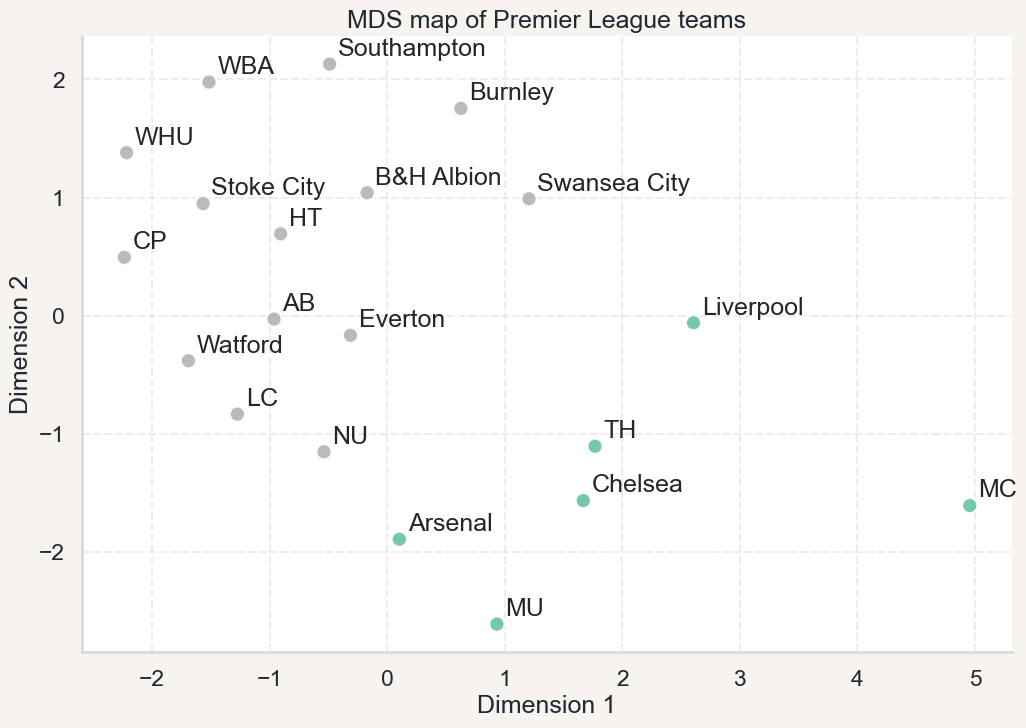

In [66]:
def short_label(team_name):
    return ''.join(part[0].upper() for part in team_name.split()) if len(team_name) > 12 else team_name

mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
mdsCoordinates = mds.fit_transform(scaledClusterData)

mdsFrame = pd.DataFrame({
    'x': mdsCoordinates[:, 0],
    'y': mdsCoordinates[:, 1],
    'team': scaledClusterData.index,
    'cluster': clusterLabels,
})

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    mdsFrame['x'],
    mdsFrame['y'],
    c=mdsFrame['cluster'],
    cmap='Set2',
    s=120,
    alpha=0.9,
    edgecolor='white',
)

for _, row in mdsFrame.iterrows():
    ax.annotate(short_label(row['team']), (row['x'], row['y']), xytext=(6, 6), textcoords='offset points')

ax.set_title('MDS map of Premier League teams')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.show()

## Final takeaways

The refined workflow points to a more defensible story than the original notebook. Chelsea now leads both ranking methods, while Tottenham, Arsenal, Manchester United, Liverpool, and Manchester City stay near the top depending on the exact scoring rule.

The important point is not only the winner, but the stability of the result. The ranking comparison shows a very high agreement between Hellwig and standardized sums, which makes the final ordering much easier to trust.

The clustering section is also stronger after standardization. Both K-means and the dendrogram separate the traditional Big 6 from the remaining clubs, and the MDS map makes that split visually easier to interpret.

From a portfolio perspective, this notebook now demonstrates:

- building a reproducible ranking workflow,
- checking whether conclusions are stable across methods,
- standardizing features before distance-based learning,
- using clustering and MDS as supporting analysis rather than decorative extras.